### 1. Setup and Environment
Import libraries and define utility functions for loading configurations.

In [3]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import glob
from datetime import datetime, timezone
from decimal import Decimal
import tqdm
import ast
import json
import importlib
import data_loader
import feature_engineering
import visualization

importlib.reload(feature_engineering)
importlib.reload(data_loader)
importlib.reload(visualization)

from data_loader import load_data_web3
from feature_engineering import build_feature_matrix
from visualization import plot_feature_distributions, plot_feature_distributions_log

### Data Collection
Fetch raw event data (Swap, Mint, Burn) from the Ethereum blockchain using a Web3 RPC endpoint for the specified block range.

In [ ]:
RPC_ENDPOINT = "https://eth-mainnet.g.alchemy.com/v2/your api key"

# config_files = sorted(glob.glob(os.path.join("config", "*.json")))
config_files = ["config/USDC_ETH_0.05_eth_config.json"]

start_block = 21525890  # 2025-01-01
end_block   = 21747950 # 2025-02-01
label       = "2025_01"

for i, config_file in enumerate(config_files, 1):
    import json
    with open(config_file) as f:
        conf = json.load(f)
    token0   = conf["token0"]
    token1   = conf["token1"]
    fee_tier = conf["fee_tier"]
    fee_str  = str(round(float(fee_tier) * 100, 4)).rstrip('0').rstrip('.')
    out_file = f"data/{token0}_{token1}_{fee_str}_{label}.parquet"

    '''
    if os.path.exists(out_file):
        print(f"  skip {out_file}")
        continue
    '''
    
    print(f"\n  [{i}/{len(config_files)}] {config_file} {label}")
    try:
        df = load_data_web3(start_block, end_block, config_file, RPC_ENDPOINT, label)
        print(f"    Done: {len(df):,} rows")
    except Exception as e:
        print(f"  ERROR: {e}")
        if hasattr(e, 'response') and e.response is not None:
            print(f"  Response body: {e.response.text}")

print("\nAll done!")


  [1/1] config/USDC_ETH_0.05_eth_config.json 2025_01
  Fetching Swap...
    [Swap] loaded from cache (185195 logs)
  Fetching Mint...
    [Mint] loaded from cache (3303 logs)
  Fetching Burn...
    [Burn] resuming from block 21705540 (2511 logs so far)
  Fetching pool liquidity for 5150 blocks...
  Saved 191,878 rows → data/USDC_ETH_0.05_2025_01.parquet
    Done: 191,878 rows

All done!


In [13]:
df = pl.read_parquet("data/USDC_ETH_0.05_2025_01.parquet")
df

blockNumber,logIndex,datetime,id,event,price,tick,liquidity,USDC,ETH,owner,tickLower,tickUpper,amount
i64,i64,"datetime[ns, UTC]",str,str,f64,f64,str,f64,f64,str,f64,f64,str
21525891,17,2025-01-01 00:00:11 UTC,"""12b61d6fd4ed1ee2ce88eeb9b8820e…","""Swap""",0.0003,195207.0,"""7352197252816085174""",-61661.863614,18.514216,null,null,null,null
21525892,221,2025-01-01 00:00:23 UTC,"""27d4f1426417fda8a9ed21cf0b6723…","""Swap""",0.0003,195207.0,"""7352197252816085174""",-16.650152,0.005,null,null,null,null
21525893,45,2025-01-01 00:00:35 UTC,"""0d455be90960ff3c36e38a9707094b…","""Swap""",0.0003,195207.0,"""7352197252816085174""",3000.0,-0.899986,null,null,null,null
21525893,181,2025-01-01 00:00:35 UTC,"""dcbe6bfd9772acb268310297a81e47…","""Swap""",0.0003,195207.0,"""7352197252816085174""",-8291.730786,2.49,null,null,null,null
21525895,137,2025-01-01 00:00:59 UTC,"""4fd2ef2515a527d64f910005ad1bbf…","""Swap""",0.0003,195208.0,"""7352197252816085174""",-6762.12137,2.030732,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
21747943,213,2025-01-31 23:58:47 UTC,"""96cec74c48d48ee58b9e5b830289e3…","""Swap""",0.000303,195312.0,"""12241678530802450636""",-82.386188,0.025,null,null,null,null
21747944,264,2025-01-31 23:58:59 UTC,"""ee59286e57f7a913f405cfdb131f99…","""Swap""",0.000303,195312.0,"""12241678530802450636""",-39.0,0.011835,null,null,null,null
21747947,58,2025-01-31 23:59:35 UTC,"""8560239c9ecdb47989c23953959b17…","""Swap""",0.000303,195312.0,"""12241678530802450636""",-200.0,0.06069,null,null,null,null


In [ ]:
# load transactionFrom
df_patched = patch_transaction_from(
    parquet_path = "data/USDC_ETH_0.05_2025_01.parquet",
    RPC_ENDPOINT = "https://eth-mainnet.g.alchemy.com/v2/WdfBIeMPovM3gmqmtei_-",
    output_path  = "data/USDC_ETH_0.05_eth_patched.parquet",
    batch_size   = 100,
)

### 3. Data Processing & Execution
Run the feature engineering pipeline for the specific pool. This cell loads the raw parquet data, computes the features, and exports the final matrix.

In [4]:
# build features
X, inter = build_feature_matrix(
    parquet_path = "data/USDC_ETH_0.05_eth_patched.parquet",
    config_path  = "config/USDC_ETH_0.05_eth_config.json",
    output_path  = "output/USDC_ETH_0.05_eth_features.parquet",
)

c:\Users\shihf\OneDrive\Desktop\NTHU_HW\pool_data\feature_engineering.py:132: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  M_liq_norm = M / abv
c:\Users\shihf\OneDrive\Desktop\NTHU_HW\pool_data\feature_engineering.py:157: RuntimeWarning: invalid value encountered in divide
  # ============================================================
c:\Users\shihf\OneDrive\Desktop\NTHU_HW\pool_data\feature_engineering.py:18: RuntimeWarning: invalid value encountered in divide
  df.filter(pl.col("event") == "Swap")
c:\Users\shihf\OneDrive\Desktop\NTHU_HW\pool_data\feature_engineering.py:202: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  "mean_width", "sd_width", "rebal_freq", "frac_jit",


In [5]:
print(X.shape)
X

(1056, 16)


agent,n_positions,n_active_blocks,mean_liq_share,mean_active_liq,sd_active_liq,mean_width,sd_width,rebal_freq,frac_jit,mean_n_trades,sd_n_trades,mean_dp,sd_dp,mean_fees,sd_fees
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
null,null,0.0,NaN,NaN,NaN,null,null,null,null,NaN,NaN,NaN,NaN,NaN,NaN
"""0x0000Aef7e12f330d0fd8BA7FeA28…",1,20949.0,0.000218,1.4962e10,3.059858e6,2550.0,0.0,0.0,0.0,1.62929,1.215896,-0.009261,2.014533,39.184184,117.98574
"""0x000ba8C5F813BC6f20F9981B6095…",1,35884.0,0.000109,8.0024e9,250359.890625,23030.0,0.0,0.0,0.0,1.652798,1.264964,-0.036089,3.364212,51.65818,175.087894
"""0x0042BD1f992cCd8727fB3Bdd6B04…",1,34504.0,0.000056,4.0161e9,1.5758e6,2100.0,0.0,0.0,0.0,1.655721,1.271389,-0.036691,3.422224,51.890862,177.659025
"""0x007A6672A921CB0580f823350e9B…",1,24747.0,0.000177,1.0101e10,1.2419e6,1950.0,0.0,0.0,0.0,1.660727,1.256453,-0.026347,3.556418,38.974458,136.98197
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""0xfa41aCE8d173053eCe556905FEb0…",2,38733.0,0.000036,2.4441e9,9.31562432e8,3560.0,500.0,0.0,0.0,1.645599,1.254699,-0.030439,3.260136,52.337957,174.024803
"""0xfb52abe04bBb360cc028C6530c5D…",1,24624.0,0.000474,2.6932e10,3.9570e6,2970.0,0.0,0.0,0.0,1.662199,1.25876,-0.026681,3.565179,38.993616,137.282512
"""0xfb9779477e5b4834BF2bC02dD29b…",6,5.0,0.982483,1.0188e16,3.9745e15,10.0,0.0,0.0,1.0,2.0,0.894427,0.0,0.0,38.808526,43.096041


### 4. Feature Distribution Analysis
Visualize the distributions of the generated features to identify outliers and verify data consistency.

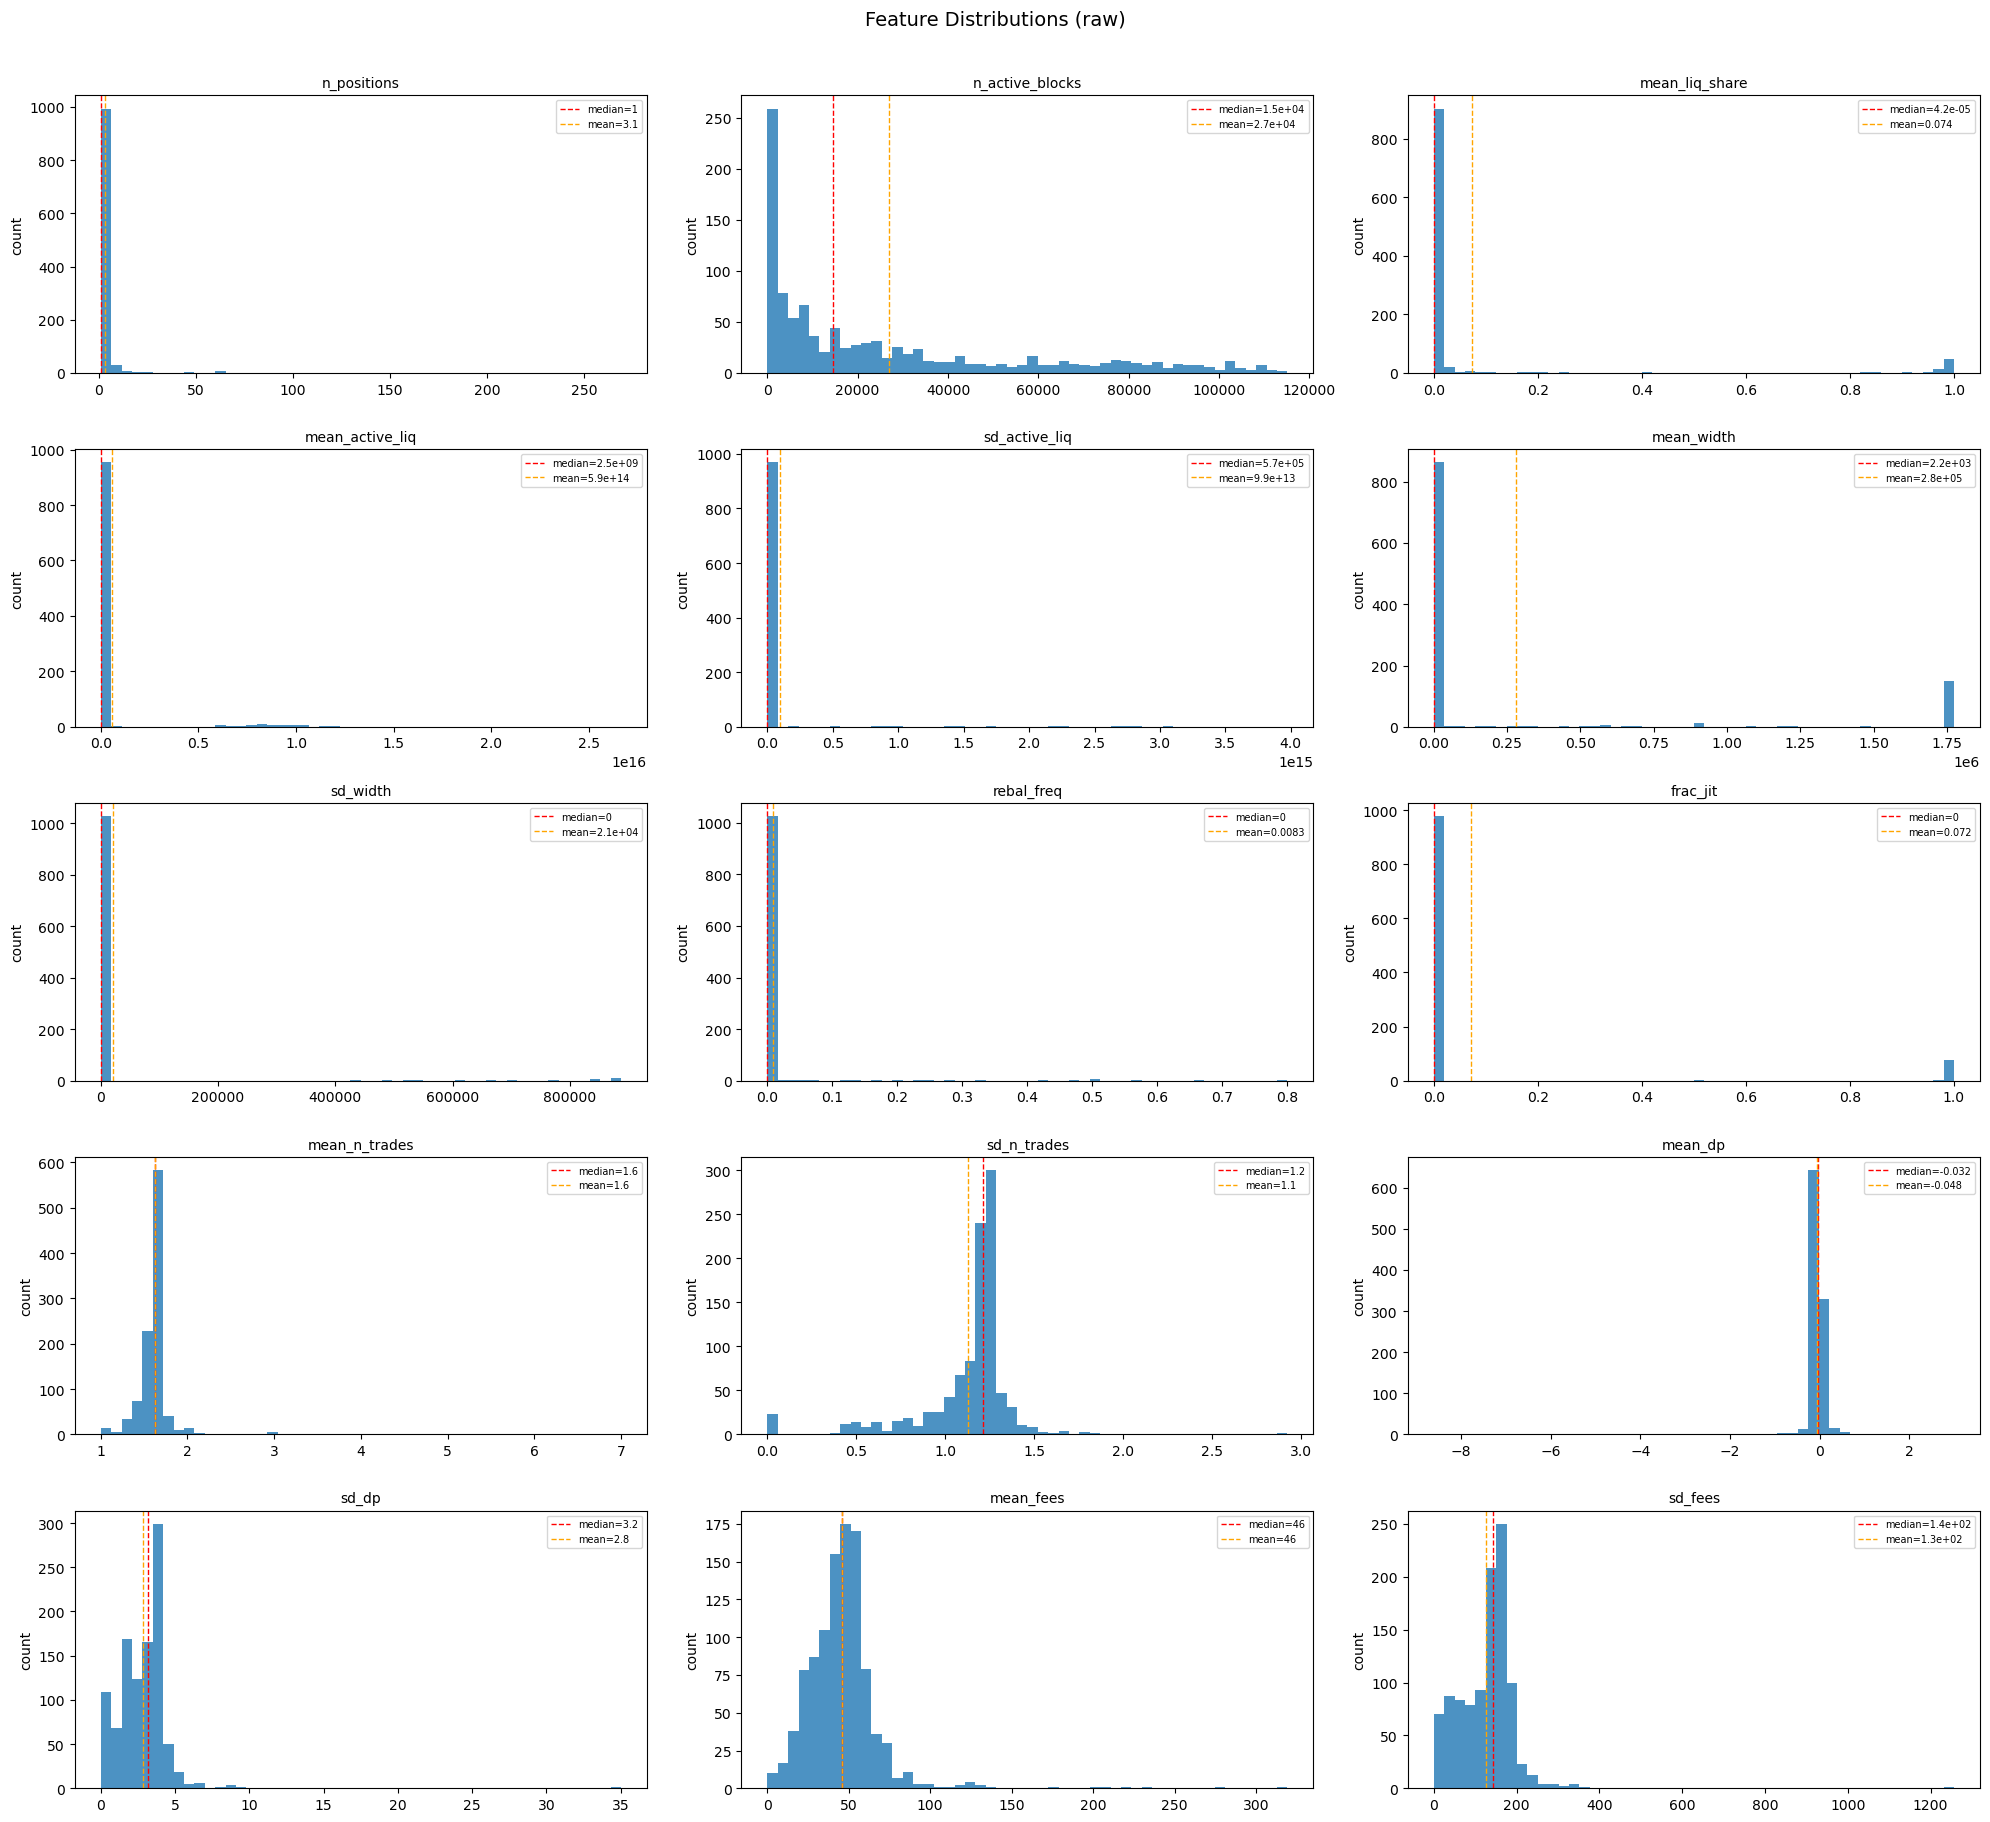

Saved to output/feature_distributions.png


In [6]:
plot_feature_distributions(X)

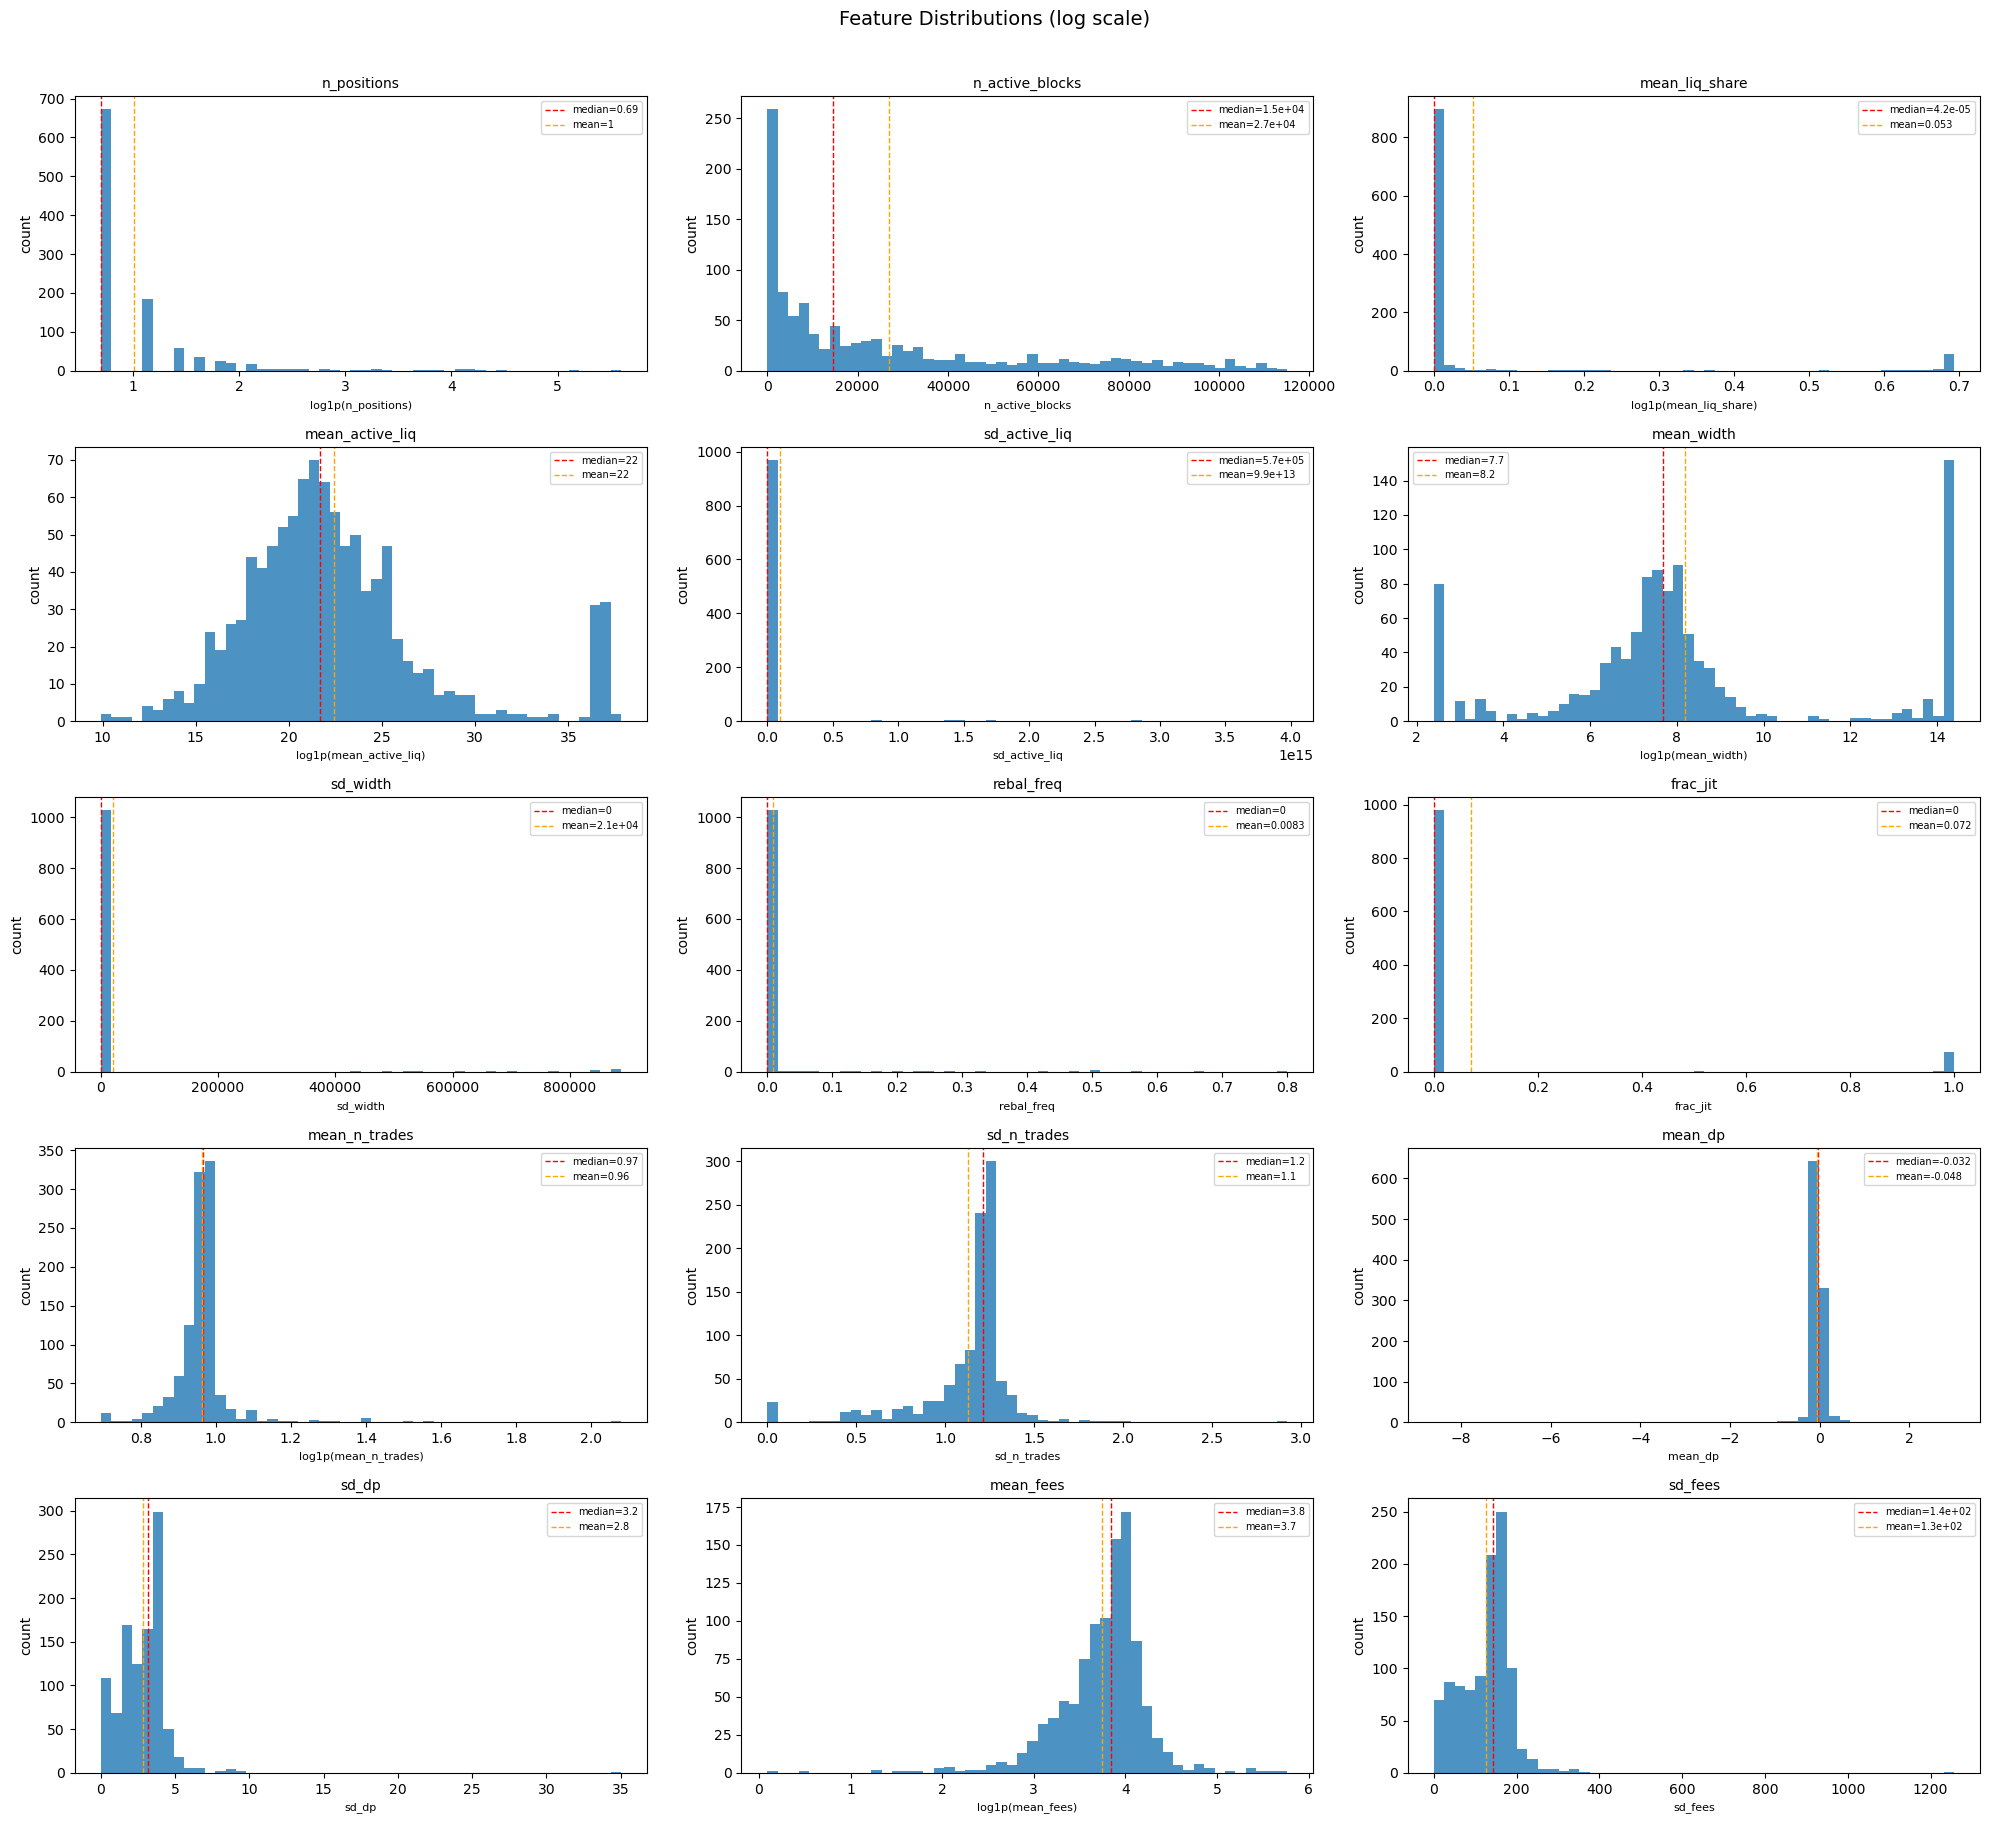

Saved to output/feature_distributions_log.png


In [7]:
plot_feature_distributions_log(X)